In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import cv2
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import precision_score, recall_score, f1_score
from PIL import Image
from tqdm import tqdm

In [3]:
PROJECT_PATH = "/content/drive/MyDrive/Mammogram_Project"

JPEG_PATH = os.path.join(PROJECT_PATH, "jpeg")

print(JPEG_PATH)

/content/drive/MyDrive/Mammogram_Project/jpeg


In [4]:
mass_train = pd.read_csv(os.path.join(PROJECT_PATH,"mass_case_description_train_set.csv"))
mass_test  = pd.read_csv(os.path.join(PROJECT_PATH,"mass_case_description_test_set.csv"))

calc_train = pd.read_csv(os.path.join(PROJECT_PATH,"calc_case_description_train_set.csv"))
calc_test  = pd.read_csv(os.path.join(PROJECT_PATH,"calc_case_description_test_set.csv"))

dicom_info = pd.read_csv(os.path.join(PROJECT_PATH,"dicom_info.csv"))
meta = pd.read_csv(os.path.join(PROJECT_PATH,"meta.csv"))

In [5]:
metadata = pd.concat(
    [mass_train, mass_test, calc_train, calc_test],
    ignore_index=True
)

metadata = metadata.dropna(subset=["breast_density"]).copy()
metadata["breast_density"] = metadata["breast_density"].astype(int)

print(metadata.shape)
metadata.head()

(1696, 17)


,patient_id,breast_density,left or right breast,image view,abnormality id,abnormality type,mass shape,mass margins,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path,breast density,calc type,calc distribution
0,P_00001,3,LEFT,CC,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,Mass-Training_P_00001_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.95...,Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.95...,NaN,NaN,NaN
1,P_00001,3,LEFT,MLO,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,Mass-Training_P_00001_LEFT_MLO/1.3.6.1.4.1.959...,Mass-Training_P_00001_LEFT_MLO_1/1.3.6.1.4.1.9...,Mass-Training_P_00001_LEFT_MLO_1/1.3.6.1.4.1.9...,NaN,NaN,NaN
2,P_00004,3,LEFT,CC,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,3,Mass-Training_P_00004_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_00004_LEFT_CC_1/1.3.6.1.4.1.95...,Mass-Training_P_00004_LEFT_CC_1/1.3.6.1.4.1.95...,NaN,NaN,NaN
3,P_00004,3,LEFT,MLO,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,3,Mass-Training_P_00004_LEFT_MLO/1.3.6.1.4.1.959...,Mass-Training_P_00004_LEFT_MLO_1/1.3.6.1.4.1.9...,Mass-Training_P_00004_LEFT_MLO_1/1.3.6.1.4.1.9...,NaN,NaN,NaN
4,P_00004,3,RIGHT,MLO,1,mass,OVAL,CIRCUMSCRIBED,4,BENIGN,5,Mass-Training_P_00004_RIGHT_MLO/1.3.6.1.4.1.95...,Mass-Training_P_00004_RIGHT_MLO_1/1.3.6.1.4.1....,Mass-Training_P_00004_RIGHT_MLO_1/1.3.6.1.4.1....,NaN,NaN,NaN


In [6]:
mammo_df = dicom_info[
    dicom_info["SeriesDescription"]=="full mammogram images"
].copy()

mask_df = dicom_info[
    dicom_info["SeriesDescription"]=="ROI mask images"
].copy()

print(len(mammo_df))
print(len(mask_df))

2857
3247


In [7]:
ROOT="/content/ddsm"

mammo_df["full_path"] = mammo_df["image_path"].apply(
    lambda x: os.path.join(ROOT,x)
)

mask_df["full_path"] = mask_df["image_path"].apply(
    lambda x: os.path.join(ROOT,x)
)

In [8]:
import re

def extract_patient(path):
    m = re.search(r'(Mass|Calc)-(Training|Test)_P_\d+_(LEFT|RIGHT)_(CC|MLO)', path)
    if m:
        return m.group(0)
    return None

In [9]:
mammo_df["PatientID"] = mammo_df["image_path"].apply(extract_patient)
mask_df["PatientID"] = mask_df["image_path"].apply(extract_patient)

In [10]:
density_dict = {}

for _, row in metadata.iterrows():

    key = row["image file path"].split("/")[0]

    density_dict[key] = row["breast_density"]

print(len(density_dict))

1592


In [11]:
mammo_dict = {}

for _, row in mammo_df.iterrows():

    mammo_dict[row["PatientID"]] = row["full_path"]

print(len(mammo_dict))

1


In [12]:
pairs=[]

for _,row in mask_df.iterrows():

    pid=row["PatientID"]

    if pid in mammo_dict and pid in density_dict:

        pairs.append(
            (
                mammo_dict[pid],
                row["full_path"],
                density_dict[pid]
            )
        )

print("Pairs:",len(pairs))

Pairs: 0


In [13]:
print("="*60)
print("Total rows:", len(mammo_df))

print("\nUnique PatientIDs:")
print(mammo_df["PatientID"].nunique())

print("\nMissing PatientIDs:")
print(mammo_df["PatientID"].isna().sum())

print("\nFirst 20 PatientIDs:")
print(mammo_df["PatientID"].head(20).tolist())

print("\nImage Path vs PatientID:")
print(mammo_df[["image_path", "PatientID"]].head(10))
print("="*60)

Total rows: 2857

Unique PatientIDs:
0

Missing PatientIDs:
2857

First 20 PatientIDs:
[None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None]

Image Path vs PatientID:
                                           image_path PatientID
1   CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.248386...      None
2   CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.267213...      None
11  CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.210396...      None
12  CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.749566...      None
15  CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.987658...      None
16  CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.362722...      None
17  CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.106891...      None
18  CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.121186...      None
23  CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.295360...      None
24  CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.146562...      None


In [14]:
pd.set_option("display.max_colwidth", None)

print("Columns:")
print(mammo_df.columns)

print("\nFirst row:")
display(mammo_df.head(1).T)

Columns:
Index(['file_path', 'image_path', 'AccessionNumber', 'BitsAllocated',
       'BitsStored', 'BodyPartExamined', 'Columns', 'ContentDate',
       'ContentTime', 'ConversionType', 'HighBit', 'InstanceNumber',
       'LargestImagePixelValue', 'Laterality', 'Modality', 'PatientBirthDate',
       'PatientID', 'PatientName', 'PatientOrientation', 'PatientSex',
       'PhotometricInterpretation', 'PixelRepresentation',
       'ReferringPhysicianName', 'Rows', 'SOPClassUID', 'SOPInstanceUID',
       'SamplesPerPixel', 'SecondaryCaptureDeviceManufacturer',
       'SecondaryCaptureDeviceManufacturerModelName', 'SeriesDescription',
       'SeriesInstanceUID', 'SeriesNumber', 'SmallestImagePixelValue',
       'SpecificCharacterSet', 'StudyDate', 'StudyID', 'StudyInstanceUID',
       'StudyTime', 'full_path'],
      dtype='object')

First row:


,1
file_path,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.248386742010678582309005372213277814849/1-249.dcm
image_path,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.248386742010678582309005372213277814849/1-249.jpg
AccessionNumber,NaN
BitsAllocated,16
BitsStored,16
BodyPartExamined,BREAST
Columns,3526
ContentDate,20160426
ContentTime,143829.101
ConversionType,WSD


In [15]:
mammo_df["PatientID"] = mammo_df["PatientName"]
mask_df["PatientID"] = mask_df["PatientName"]

In [16]:
print("Unique mammo IDs:", mammo_df["PatientID"].nunique())
print("Unique mask IDs :", mask_df["PatientID"].nunique())

Unique mammo IDs: 2857
Unique mask IDs : 3247


In [17]:
mammo_dict = {}

for _, row in mammo_df.iterrows():
    mammo_dict[row["PatientID"]] = row["full_path"]

print(len(mammo_dict))

2857


In [18]:
pairs = []

for _, row in mask_df.iterrows():

    pid = row["PatientID"]

    if pid in mammo_dict and pid in density_dict:

        pairs.append(
            (
                mammo_dict[pid],
                row["full_path"],
                density_dict[pid]
            )
        )

print("Pairs:", len(pairs))

Pairs: 0


In [19]:
print("Sample mammo IDs:")
print(mammo_df["PatientID"].head(5).tolist())

print("\nSample mask IDs:")
print(mask_df["PatientID"].head(5).tolist())

print("\nSample density IDs:")
print(list(density_dict.keys())[:5])

print("\nChecking first mask ID:")
first_mask = mask_df["PatientID"].iloc[0]
print(first_mask)
print("Exists in mammo_dict :", first_mask in mammo_dict)
print("Exists in density_dict:", first_mask in density_dict)

print("\nChecking first density key:")
first_density = list(density_dict.keys())[0]
print(first_density)
print("Exists in mammo_dict :", first_density in mammo_dict)

Sample mammo IDs:
['Mass-Training_P_01754_RIGHT_CC', 'Calc-Training_P_00232_RIGHT_CC', 'Mass-Training_P_01206_RIGHT_MLO', 'Calc-Training_P_00506_RIGHT_MLO', 'Calc-Training_P_01823_RIGHT_CC']

Sample mask IDs:
['Calc-Training_P_00181_RIGHT_CC_1', 'Calc-Training_P_01015_LEFT_CC_1', 'Calc-Training_P_01497_LEFT_CC_1', 'Mass-Training_P_00242_RIGHT_CC_1', 'Mass-Training_P_00634_RIGHT_MLO_1']

Sample density IDs:
['Mass-Training_P_00001_LEFT_CC', 'Mass-Training_P_00001_LEFT_MLO', 'Mass-Training_P_00004_LEFT_CC', 'Mass-Training_P_00004_LEFT_MLO', 'Mass-Training_P_00004_RIGHT_MLO']

Checking first mask ID:
Calc-Training_P_00181_RIGHT_CC_1
Exists in mammo_dict : False
Exists in density_dict: False

Checking first density key:
Mass-Training_P_00001_LEFT_CC
Exists in mammo_dict : True


In [20]:
mask_df["PatientID"] = mask_df["PatientName"].str.rsplit("_", n=1).str[0]

In [21]:
print(mask_df["PatientID"].head())

5      Calc-Training_P_00181_RIGHT_CC
8       Calc-Training_P_01015_LEFT_CC
9       Calc-Training_P_01497_LEFT_CC
14     Mass-Training_P_00242_RIGHT_CC
20    Mass-Training_P_00634_RIGHT_MLO
Name: PatientID, dtype: object


In [22]:
pairs = []

for _, row in mask_df.iterrows():

    pid = row["PatientID"]

    if pid in mammo_dict and pid in density_dict:

        pairs.append(
            (
                mammo_dict[pid],
                row["full_path"],
                density_dict[pid]
            )
        )

print("Pairs:", len(pairs))

Pairs: 1696


In [23]:
X = []
Y = []
D = []

for img_path, mask_path, density in pairs:

    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    if img is None or mask is None:
        continue

    img = cv2.resize(img, (512, 512))
    mask = cv2.resize(mask, (512, 512))

    mask = (mask > 127).astype(np.uint8)

    X.append(img)
    Y.append(mask)
    D.append(density)

X = np.array(X, dtype=np.uint8)
Y = np.array(Y, dtype=np.uint8)
D = np.array(D, dtype=np.uint8)

print("X:", X.shape)
print("Y:", Y.shape)
print("Density:", D.shape)

X: (0,)
Y: (0,)
Density: (0,)


In [24]:
save_path = "/content/drive/MyDrive/Mammogram_Project"

np.save(f"{save_path}/density_x.npy", X)
np.save(f"{save_path}/density_y.npy", Y)
np.save(f"{save_path}/density_labels.npy", D)

print("Saved successfully!")

Saved successfully!


In [25]:
print(np.unique(D, return_counts=True))

(array([], dtype=uint8), array([], dtype=int64))


In [26]:
print(pairs[0])

('/content/ddsm/CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.330740809913644315209371578112284206839/1-146.jpg', '/content/ddsm/CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.236373548712994183418851990043419770402/2-086.jpg', 2)


In [27]:
print(mask_df[["file_path", "image_path"]].head())

                                                                                     file_path  \
5   CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.153339052913121382622526066491844156138/2-270.dcm   
8   CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.178994714611485132105265512043047466091/2-127.dcm   
9   CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.411833492612373627114350673042828631265/2-281.dcm   
14  CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.236373548712994183418851990043419770402/2-086.dcm   
20  CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.357008050412534761329866492500201501919/1-241.dcm   

                                                                                   image_path  
5   CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.153339052913121382622526066491844156138/2-270.jpg  
8   CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.178994714611485132105265512043047466091/2-127.jpg  
9   CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.411833492612373627114350673042828631265/2-281.jpg  
14  CBIS-DDSM/jpeg/1.3.6.1.

In [28]:
print(mask_df["SeriesDescription"].head())

5     ROI mask images
8     ROI mask images
9     ROI mask images
14    ROI mask images
20    ROI mask images
Name: SeriesDescription, dtype: object


In [29]:
print(mask_df["full_path"].iloc[0])

/content/ddsm/CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.153339052913121382622526066491844156138/2-270.jpg


In [30]:
import os

mask_path = mask_df["full_path"].iloc[0]

print(os.path.exists(mask_path))
print(mask_path)

False
/content/ddsm/CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.153339052913121382622526066491844156138/2-270.jpg


In [31]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open(mask_df["full_path"].iloc[0])

plt.imshow(img, cmap="gray")
plt.axis("off")
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/content/ddsm/CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.153339052913121382622526066491844156138/2-270.jpg'

In [32]:
!find /content/ddsm -name "2-270.jpg"

find: ‘/content/ddsm’: No such file or directory


In [33]:
!find /content/ddsm -name "*270.jpg"

find: ‘/content/ddsm’: No such file or directory


In [34]:
!find /content/ddsm -name "1.3.6.1.4.1.9590.100.1.2.153339052913121382622526066491844156138"

find: ‘/content/ddsm’: No such file or directory


In [35]:
!find /content/ddsm -maxdepth 3 -type d

find: ‘/content/ddsm’: No such file or directory


In [36]:
!ls /content

drive  sample_data


In [37]:
!find /content/drive/MyDrive -maxdepth 3 -type d | grep -i "CBIS"

In [38]:
!find /content/drive/MyDrive -maxdepth 4 -type d | grep -i "jpeg"

/content/drive/MyDrive/Mammogram_Project/jpeg
/content/drive/MyDrive/Mammogram_Project/jpeg/1.3.6.1.4.1.9590.100.1.2.159689052311613969236897222572223478612
/content/drive/MyDrive/Mammogram_Project/jpeg/1.3.6.1.4.1.9590.100.1.2.159478518911041568122069026733751473954
/content/drive/MyDrive/Mammogram_Project/jpeg/1.3.6.1.4.1.9590.100.1.2.159295429412197823619100107812609179925
/content/drive/MyDrive/Mammogram_Project/jpeg/1.3.6.1.4.1.9590.100.1.2.159163762312152516407821723321933485165
/content/drive/MyDrive/Mammogram_Project/jpeg/1.3.6.1.4.1.9590.100.1.2.159291141810912015217099519221852402492
/content/drive/MyDrive/Mammogram_Project/jpeg/1.3.6.1.4.1.9590.100.1.2.159443656311747130733554507872945786561
/content/drive/MyDrive/Mammogram_Project/jpeg/1.3.6.1.4.1.9590.100.1.2.159046574612998673315083542350464494818
/content/drive/MyDrive/Mammogram_Project/jpeg/1.3.6.1.4.1.9590.100.1.2.158994694612173333101913801030238486766
/content/drive/MyDrive/Mammogram_Project/jpeg/1.3.6.1.4.1.9590.100

In [39]:
print(mammo_df["full_path"].iloc[0])
print(mask_df["full_path"].iloc[0])

/content/ddsm/CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.248386742010678582309005372213277814849/1-249.jpg
/content/ddsm/CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.153339052913121382622526066491844156138/2-270.jpg


In [40]:
print(PROJECT_PATH)

/content/drive/MyDrive/Mammogram_Project


In [41]:
import os

mammo_df["full_path"] = mammo_df["image_path"].apply(
    lambda x: os.path.join(PROJECT_PATH, x.replace("CBIS-DDSM/", ""))
)

mask_df["full_path"] = mask_df["image_path"].apply(
    lambda x: os.path.join(PROJECT_PATH, x.replace("CBIS-DDSM/", ""))
)

print(mammo_df["full_path"].iloc[0])
print(mask_df["full_path"].iloc[0])

/content/drive/MyDrive/Mammogram_Project/jpeg/1.3.6.1.4.1.9590.100.1.2.248386742010678582309005372213277814849/1-249.jpg
/content/drive/MyDrive/Mammogram_Project/jpeg/1.3.6.1.4.1.9590.100.1.2.153339052913121382622526066491844156138/2-270.jpg


In [42]:
print(os.path.exists(mammo_df["full_path"].iloc[0]))
print(os.path.exists(mask_df["full_path"].iloc[0]))

True
True


In [43]:
pairs = []

for _, row in mask_df.iterrows():

    pid = row["PatientID"]

    if pid in mammo_dict and pid in density_dict:

        pairs.append((
            mammo_dict[pid],
            row["full_path"],
            density_dict[pid]
        ))

print("Pairs:", len(pairs))

Pairs: 1696


In [44]:
print(pairs[0])

import os

print("Image exists:", os.path.exists(pairs[0][0]))
print("Mask exists :", os.path.exists(pairs[0][1]))

('/content/ddsm/CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.330740809913644315209371578112284206839/1-146.jpg', '/content/drive/MyDrive/Mammogram_Project/jpeg/1.3.6.1.4.1.9590.100.1.2.236373548712994183418851990043419770402/2-086.jpg', 2)
Image exists: False
Mask exists : True


In [45]:
import cv2

img = cv2.imread(pairs[0][0], cv2.IMREAD_GRAYSCALE)
mask = cv2.imread(pairs[0][1], cv2.IMREAD_GRAYSCALE)

print("Image:", img is None)
print("Mask :", mask is None)

if img is not None:
    print("Image shape:", img.shape)

if mask is not None:
    print("Mask shape:", mask.shape)

Image: True
Mask : False
Mask shape: (4600, 2760)


In [46]:
print(mammo_df[["PatientID","full_path"]].head(10))

                          PatientID  \
1    Mass-Training_P_01754_RIGHT_CC   
2    Calc-Training_P_00232_RIGHT_CC   
11  Mass-Training_P_01206_RIGHT_MLO   
12  Calc-Training_P_00506_RIGHT_MLO   
15   Calc-Training_P_01823_RIGHT_CC   
16  Mass-Training_P_00122_RIGHT_MLO   
17  Mass-Training_P_01175_RIGHT_MLO   
18   Mass-Training_P_00411_RIGHT_CC   
23   Mass-Training_P_00004_LEFT_MLO   
24   Mass-Training_P_01946_RIGHT_CC   

                                                                                                                   full_path  
1   /content/drive/MyDrive/Mammogram_Project/jpeg/1.3.6.1.4.1.9590.100.1.2.248386742010678582309005372213277814849/1-249.jpg  
2   /content/drive/MyDrive/Mammogram_Project/jpeg/1.3.6.1.4.1.9590.100.1.2.267213171011171858918434139331210917771/1-032.jpg  
11  /content/drive/MyDrive/Mammogram_Project/jpeg/1.3.6.1.4.1.9590.100.1.2.210396893911234385024533119100226540488/1-128.jpg  
12   /content/drive/MyDrive/Mammogram_Project/jpeg/1.3.6.1.4.1

In [47]:
pid = pairs[0][0]

print(
    mammo_df[
        mammo_df["PatientID"] == "Mass-Training_P_01754_RIGHT_CC"
    ][["image_path","full_path"]]
)

                                                                                  image_path  \
1  CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.248386742010678582309005372213277814849/1-249.jpg   

                                                                                                                  full_path  
1  /content/drive/MyDrive/Mammogram_Project/jpeg/1.3.6.1.4.1.9590.100.1.2.248386742010678582309005372213277814849/1-249.jpg  


In [48]:
mammo_dict = {}

for _, row in mammo_df.iterrows():
    mammo_dict[row["PatientID"]] = row["full_path"]

print("Mammo dict:", len(mammo_dict))

Mammo dict: 2857


In [49]:
pairs = []

for _, row in mask_df.iterrows():

    pid = row["PatientID"]

    if pid in mammo_dict and pid in density_dict:

        pairs.append((
            mammo_dict[pid],
            row["full_path"],
            density_dict[pid]
        ))

print("Pairs:", len(pairs))

Pairs: 1696


In [50]:
import os

print(pairs[0])

print(os.path.exists(pairs[0][0]))
print(os.path.exists(pairs[0][1]))

('/content/drive/MyDrive/Mammogram_Project/jpeg/1.3.6.1.4.1.9590.100.1.2.330740809913644315209371578112284206839/1-146.jpg', '/content/drive/MyDrive/Mammogram_Project/jpeg/1.3.6.1.4.1.9590.100.1.2.236373548712994183418851990043419770402/2-086.jpg', 2)
True
True


In [51]:
print(mammo_df[mammo_df["PatientID"] == "Mass-Training_P_01754_RIGHT_CC"]
      [["image_path","SeriesInstanceUID","StudyInstanceUID"]])

print()

print(mask_df[mask_df["PatientID"] == "Mass-Training_P_01754_RIGHT_CC"]
      [["image_path","SeriesInstanceUID","StudyInstanceUID"]])

                                                                                  image_path  \
1  CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.248386742010678582309005372213277814849/1-249.jpg   

                                                  SeriesInstanceUID  \
1  1.3.6.1.4.1.9590.100.1.2.248386742010678582309005372213277814849   

                                                   StudyInstanceUID  
1  1.3.6.1.4.1.9590.100.1.2.161516517311681906612443997862211969669  

                                                                                     image_path  \
2137  CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.157873313111008204717745471110978322176/2-223.jpg   

                                                     SeriesInstanceUID  \
2137  1.3.6.1.4.1.9590.100.1.2.157873313111008204717745471110978322176   

                                                     StudyInstanceUID  
2137  1.3.6.1.4.1.9590.100.1.2.36269991012428194134391218252300483206  


In [52]:
full_df = dicom_info[
    dicom_info["SeriesDescription"] == "full mammogram images"
].copy()

crop_df = dicom_info[
    dicom_info["SeriesDescription"] == "cropped images"
].copy()

mask_df = dicom_info[
    dicom_info["SeriesDescription"] == "ROI mask images"
].copy()

print(len(full_df), len(crop_df), len(mask_df))

2857 3567 3247


In [53]:
full_df["PatientID"] = full_df["PatientName"]

crop_df["PatientID"] = crop_df["PatientName"]

mask_df["PatientID"] = (
    mask_df["PatientName"]
    .str.rsplit("_", n=1)
    .str[0]
)

In [54]:
import os

PROJECT_PATH="/content/drive/MyDrive/Mammogram_Project"

for df in [full_df,crop_df,mask_df]:
    df["full_path"]=df["image_path"].apply(
        lambda x: os.path.join(
            PROJECT_PATH,
            x.replace("CBIS-DDSM/","")
        )
    )

In [55]:
metadata = pd.concat(
    [mass_train,mass_test,calc_train,calc_test],
    ignore_index=True
)

metadata = metadata.dropna(subset=["breast_density"])

metadata["breast_density"] = metadata["breast_density"].astype(int)

metadata["PatientID"] = metadata["image file path"].apply(
    lambda x:x.split("/")[0]
)

In [56]:
density_dict = dict(
    zip(
        metadata["PatientID"],
        metadata["breast_density"]
    )
)

In [57]:
print(metadata.columns.tolist())

['patient_id', 'breast_density', 'left or right breast', 'image view', 'abnormality id', 'abnormality type', 'mass shape', 'mass margins', 'assessment', 'pathology', 'subtlety', 'image file path', 'cropped image file path', 'ROI mask file path', 'breast density', 'calc type', 'calc distribution', 'PatientID']


In [58]:
metadata["mammo_id"] = metadata["image file path"].apply(
    lambda x: x.split("/")[0]
)

metadata["crop_id"] = metadata["cropped image file path"].apply(
    lambda x: x.split("/")[0]
)

metadata["mask_id"] = metadata["ROI mask file path"].apply(
    lambda x: x.split("/")[0]
)

In [59]:
density_dict = dict(
    zip(
        metadata["mammo_id"],
        metadata["breast_density"]
    )
)

In [60]:
mammo_dict = dict(
    zip(
        full_df["PatientID"],
        full_df["full_path"]
    )
)

crop_dict = dict(
    zip(
        crop_df["PatientID"],
        crop_df["full_path"]
    )
)

mask_dict = dict(
    zip(
        mask_df["PatientID"],
        mask_df["full_path"]
    )
)

In [61]:
pairs = []

for _, row in metadata.iterrows():

    mammo = row["mammo_id"]
    mask = row["mask_id"]

    if (
        mammo in mammo_dict
        and mask in mask_dict
    ):

        pairs.append(
            (
                mammo_dict[mammo],
                mask_dict[mask],
                row["breast_density"]
            )
        )

print("Pairs:", len(pairs))

Pairs: 0


In [62]:
print("Sample mammo_dict keys:")
print(list(mammo_dict.keys())[:5])

print("\nSample mask_dict keys:")
print(list(mask_dict.keys())[:5])

print("\nSample metadata mammo_id:")
print(metadata["mammo_id"].head().tolist())

print("\nSample metadata mask_id:")
print(metadata["mask_id"].head().tolist())

print("\nCommon mammogram IDs:",
      len(set(mammo_dict.keys()) & set(metadata["mammo_id"])))

print("Common mask IDs:",
      len(set(mask_dict.keys()) & set(metadata["mask_id"])))

Sample mammo_dict keys:
['Mass-Training_P_01754_RIGHT_CC', 'Calc-Training_P_00232_RIGHT_CC', 'Mass-Training_P_01206_RIGHT_MLO', 'Calc-Training_P_00506_RIGHT_MLO', 'Calc-Training_P_01823_RIGHT_CC']

Sample mask_dict keys:
['Calc-Training_P_00181_RIGHT_CC', 'Calc-Training_P_01015_LEFT_CC', 'Calc-Training_P_01497_LEFT_CC', 'Mass-Training_P_00242_RIGHT_CC', 'Mass-Training_P_00634_RIGHT_MLO']

Sample metadata mammo_id:
['Mass-Training_P_00001_LEFT_CC', 'Mass-Training_P_00001_LEFT_MLO', 'Mass-Training_P_00004_LEFT_CC', 'Mass-Training_P_00004_LEFT_MLO', 'Mass-Training_P_00004_RIGHT_MLO']

Sample metadata mask_id:
['Mass-Training_P_00001_LEFT_CC_1', 'Mass-Training_P_00001_LEFT_MLO_1', 'Mass-Training_P_00004_LEFT_CC_1', 'Mass-Training_P_00004_LEFT_MLO_1', 'Mass-Training_P_00004_RIGHT_MLO_1']

Common mammogram IDs: 1592
Common mask IDs: 0


In [63]:
metadata["mask_id"] = (
    metadata["ROI mask file path"]
    .apply(lambda x: x.split("/")[0])
    .str.rsplit("_", n=1)
    .str[0]
)

In [64]:
print(
    "Common mask IDs:",
    len(set(mask_dict.keys()) & set(metadata["mask_id"]))
)

Common mask IDs: 1592


In [65]:
pairs = []

for _, row in metadata.iterrows():

    mammo = row["mammo_id"]
    mask = row["mask_id"]

    if mammo in mammo_dict and mask in mask_dict:

        pairs.append(
            (
                mammo_dict[mammo],
                mask_dict[mask],
                row["breast_density"]
            )
        )

print("Pairs:", len(pairs))

Pairs: 1696


In [66]:
import os
import cv2

print(pairs[0])

img_path, mask_path, density = pairs[0]

print("Image exists :", os.path.exists(img_path))
print("Mask exists  :", os.path.exists(mask_path))

img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

print("Image None:", img is None)
print("Mask None :", mask is None)

if img is not None:
    print("Image shape:", img.shape)

if mask is not None:
    print("Mask shape:", mask.shape)

('/content/drive/MyDrive/Mammogram_Project/jpeg/1.3.6.1.4.1.9590.100.1.2.342386194811267636608694132590482924515/1-211.jpg', '/content/drive/MyDrive/Mammogram_Project/jpeg/1.3.6.1.4.1.9590.100.1.2.296736403313792599626368780122205399650/1-250.jpg', 3)
Image exists : True
Mask exists  : True
Image None: False
Mask None : False
Image shape: (4808, 3024)
Mask shape: (4808, 3024)


In [67]:
X, Y, D = [], [], []

for img_path, mask_path, density in pairs:

    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    if img is None or mask is None:
        continue

    img = cv2.resize(img, (512, 512))
    mask = cv2.resize(mask, (512, 512), interpolation=cv2.INTER_NEAREST)

    mask = (mask > 127).astype(np.uint8)

    X.append(img)
    Y.append(mask)
    D.append(density)

X = np.array(X, dtype=np.uint8)
Y = np.array(Y, dtype=np.uint8)
D = np.array(D, dtype=np.uint8)

print("X:", X.shape)
print("Y:", Y.shape)
print("D:", D.shape)

X: (1696, 512, 512)
Y: (1696, 512, 512)
D: (1696,)


In [68]:
import numpy as np

unique, counts = np.unique(D, return_counts=True)

for u, c in zip(unique, counts):
    print(f"Density {u}: {c}")

Density 1: 337
Density 2: 757
Density 3: 449
Density 4: 153


In [69]:
save_path = "/content/drive/MyDrive/Mammogram_Project"

np.save(f"{save_path}/density_x.npy", X)
np.save(f"{save_path}/density_y.npy", Y)
np.save(f"{save_path}/density_labels.npy", D)

print("Saved successfully!")

Saved successfully!


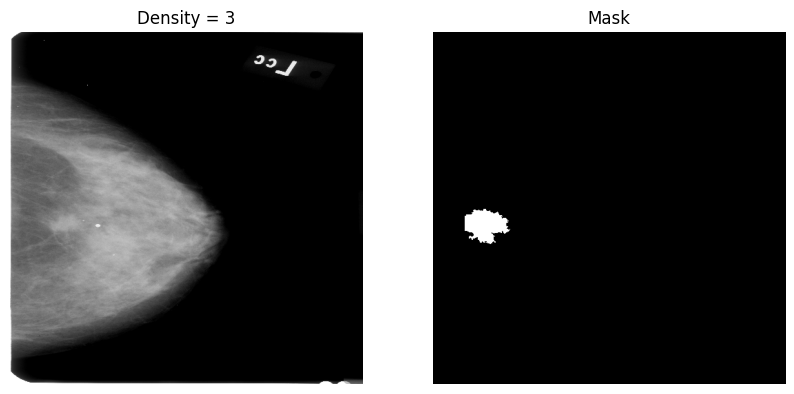

In [70]:
import matplotlib.pyplot as plt

idx = 0

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(X[idx], cmap="gray")
plt.title(f"Density = {D[idx]}")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(Y[idx], cmap="gray")
plt.title("Mask")
plt.axis("off")

plt.show()

In [71]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm

# Output folder
SAVE_DIR = "/content/drive/MyDrive/Mammogram_Project/Preprocessed_Density"

os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(os.path.join(SAVE_DIR, "images"), exist_ok=True)
os.makedirs(os.path.join(SAVE_DIR, "masks"), exist_ok=True)

print(SAVE_DIR)

/content/drive/MyDrive/Mammogram_Project/Preprocessed_Density


In [72]:
sample_idx = 0

img_path, mask_path, density = pairs[sample_idx]

print(img_path)
print(mask_path)
print("Density:", density)

image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

print(image.shape)
print(mask.shape)

/content/drive/MyDrive/Mammogram_Project/jpeg/1.3.6.1.4.1.9590.100.1.2.342386194811267636608694132590482924515/1-211.jpg
/content/drive/MyDrive/Mammogram_Project/jpeg/1.3.6.1.4.1.9590.100.1.2.296736403313792599626368780122205399650/1-250.jpg
Density: 3
(4808, 3024)
(4808, 3024)


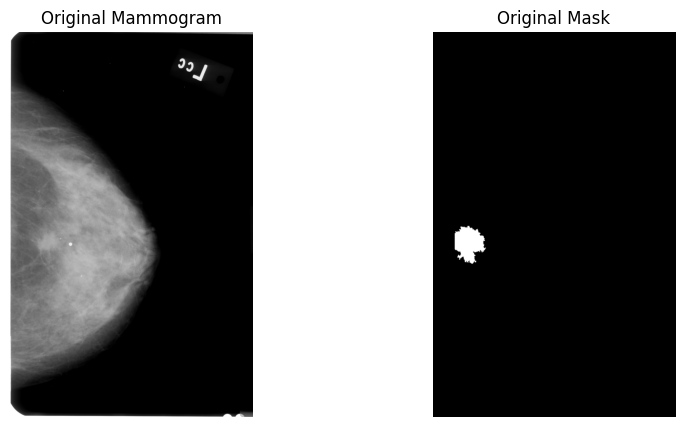

In [73]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image,cmap="gray")
plt.title("Original Mammogram")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask,cmap="gray")
plt.title("Original Mask")
plt.axis("off")

plt.show()

In [82]:
fixed_img, fixed_mask = orientation_fix(image, mask)

In [83]:
import cv2
import numpy as np

def orientation_fix(img, mask):
    """
    Make every mammogram look like:
           Breast on RIGHT
           Nipple pointing LEFT
    """

    binary = (img > 10).astype(np.uint8)

    left_pixels = binary[:, :img.shape[1]//2].sum()
    right_pixels = binary[:, img.shape[1]//2:].sum()

    # If breast is on LEFT, flip horizontally
    if left_pixels > right_pixels:
        img = cv2.flip(img, 1)
        mask = cv2.flip(mask, 1)

    return img, mask

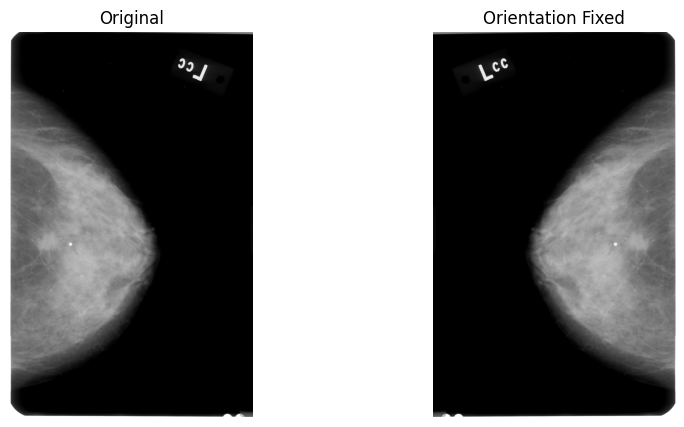

In [84]:
fixed_img, fixed_mask = orientation_fix(image, mask)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(fixed_img, cmap="gray")
plt.title("Orientation Fixed")
plt.axis("off")

plt.show()

In [85]:
def artifact_removal(img):
    """
    Remove labels/artifacts while preserving the breast.
    """

    _, binary = cv2.threshold(img, 10, 255, cv2.THRESH_BINARY)

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary)

    largest = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])

    breast_mask = (labels == largest).astype(np.uint8)

    cleaned = img * breast_mask

    return cleaned

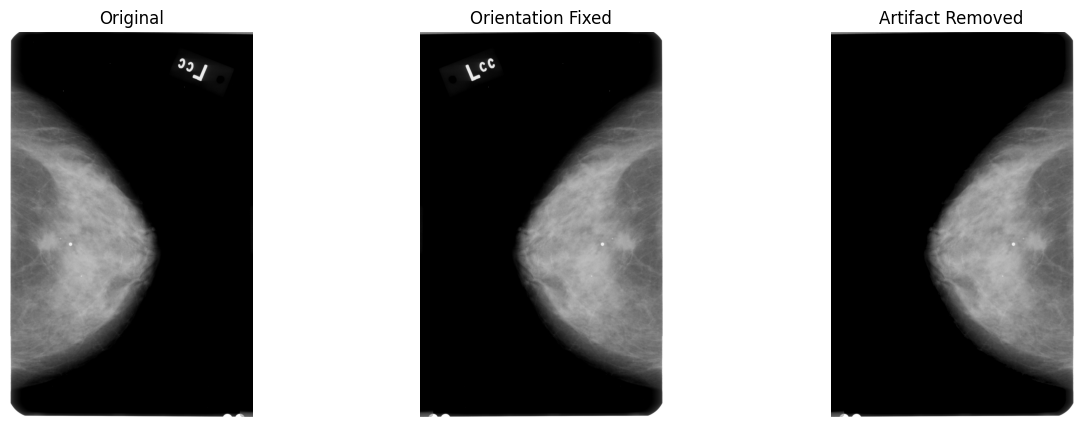

In [86]:
artifact = artifact_removal(fixed_img)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(image,cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(fixed_img,cmap='gray')
plt.title("Orientation Fixed")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(artifact,cmap='gray')
plt.title("Artifact Removed")
plt.axis("off")

plt.show()

In [87]:
def clahe_enhancement(img):
    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8,8)
    )
    return clahe.apply(img)

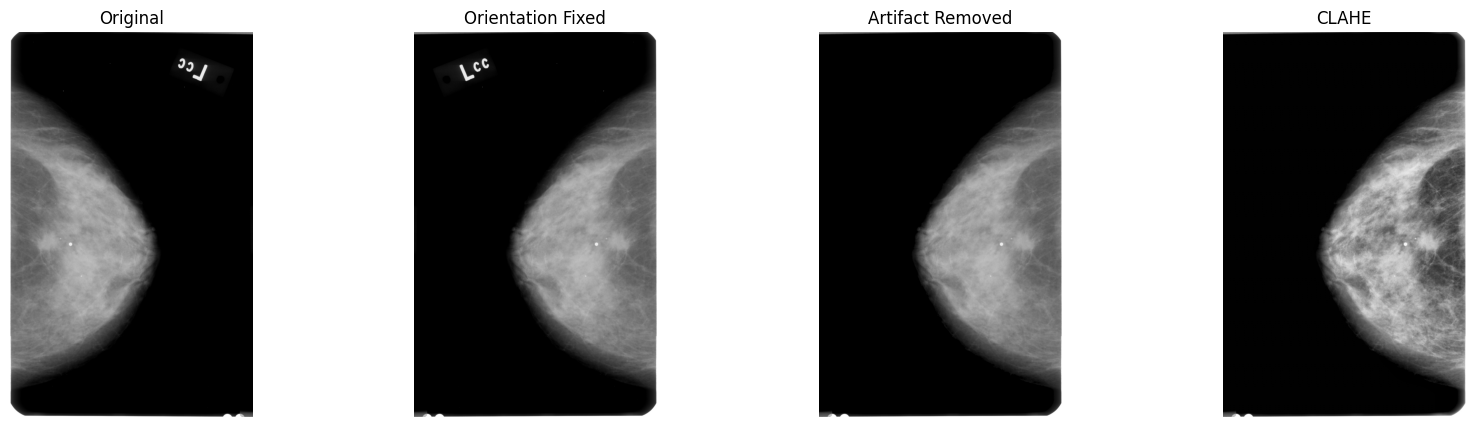

In [88]:
clahe_img = clahe_enhancement(artifact)

plt.figure(figsize=(20,5))

titles = [
    "Original",
    "Orientation Fixed",
    "Artifact Removed",
    "CLAHE"
]

images = [
    image,
    fixed_img,
    artifact,
    clahe_img
]

for i in range(4):
    plt.subplot(1,4,i+1)
    plt.imshow(images[i], cmap="gray")
    plt.title(titles[i])
    plt.axis("off")

plt.show()

In [89]:
def gaussian_blur(img):
    return cv2.GaussianBlur(img, (5,5), 0)

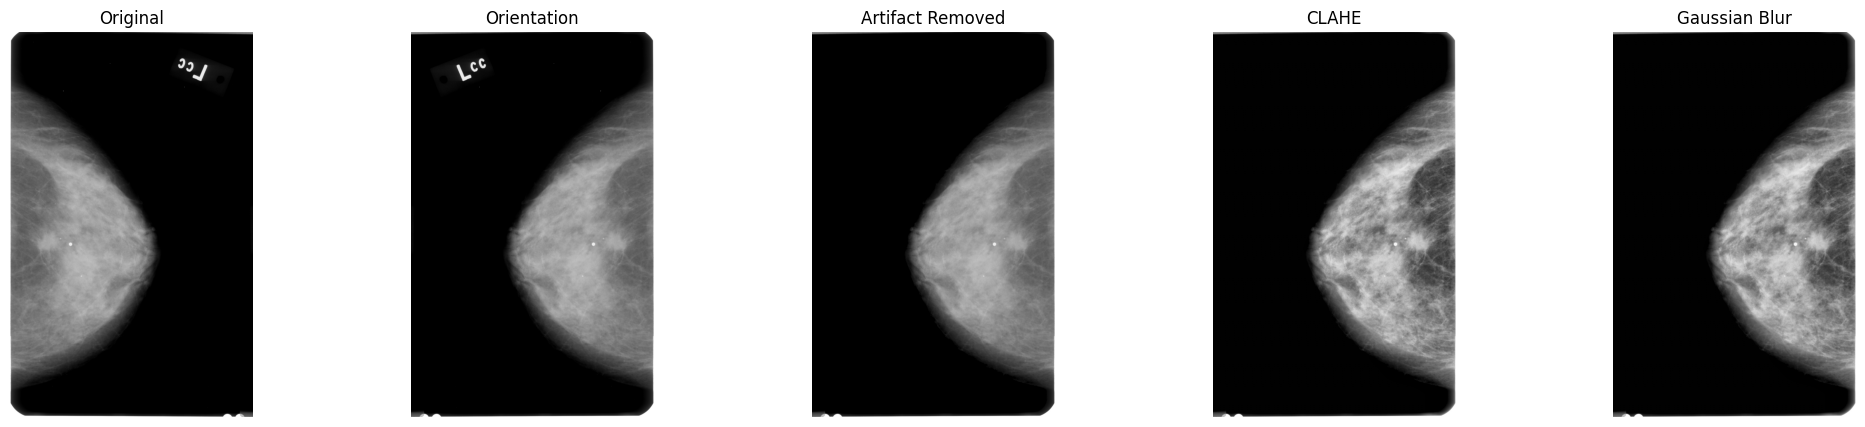

In [90]:
blur = gaussian_blur(clahe_img)

plt.figure(figsize=(25,5))

titles = [
    "Original",
    "Orientation",
    "Artifact Removed",
    "CLAHE",
    "Gaussian Blur"
]

imgs = [
    image,
    fixed_img,
    artifact,
    clahe_img,
    blur
]

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(imgs[i], cmap="gray")
    plt.title(titles[i])
    plt.axis("off")

plt.show()

In [91]:
resize_img = cv2.resize(
    blur,
    (512,512),
    interpolation=cv2.INTER_AREA
)

resize_mask = cv2.resize(
    fixed_mask,
    (512,512),
    interpolation=cv2.INTER_NEAREST
)

In [92]:
norm_img = resize_img.astype(np.float32)/255.0

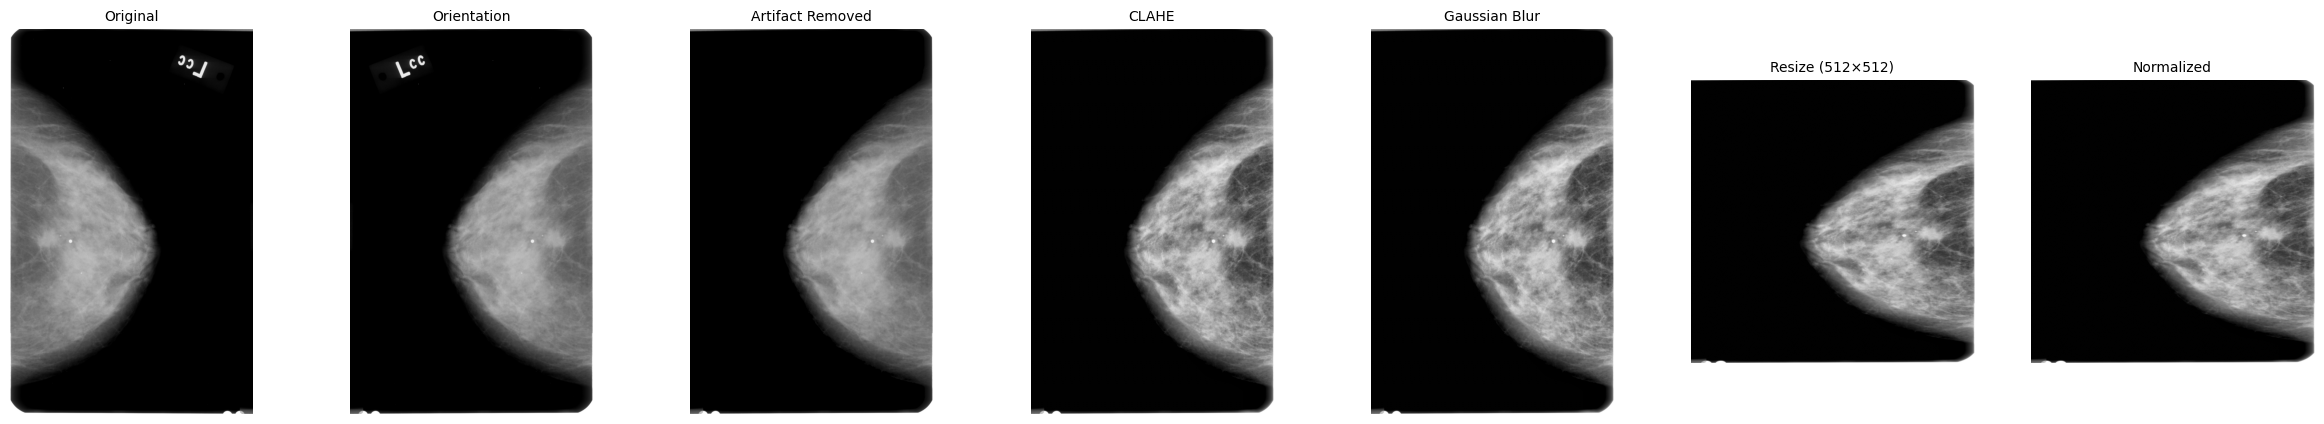

In [93]:
plt.figure(figsize=(30,5))

imgs = [
    image,
    fixed_img,
    artifact,
    clahe_img,
    blur,
    resize_img,
    norm_img
]

titles = [
    "Original",
    "Orientation",
    "Artifact Removed",
    "CLAHE",
    "Gaussian Blur",
    "Resize (512×512)",
    "Normalized"
]

for i in range(len(imgs)):
    plt.subplot(1,len(imgs),i+1)
    plt.imshow(imgs[i], cmap='gray')
    plt.title(titles[i], fontsize=10)
    plt.axis('off')

plt.show()

In [94]:
mask_bin = (resize_mask > 0).astype(np.uint8)

ys, xs = np.where(mask_bin > 0)

x1, x2 = xs.min(), xs.max()
y1, y2 = ys.min(), ys.max()

print(x1, y1, x2, y2)

401 258 467 309


In [95]:
padding = 30

x1 = max(0, x1 - padding)
y1 = max(0, y1 - padding)

x2 = min(512, x2 + padding)
y2 = min(512, y2 + padding)

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

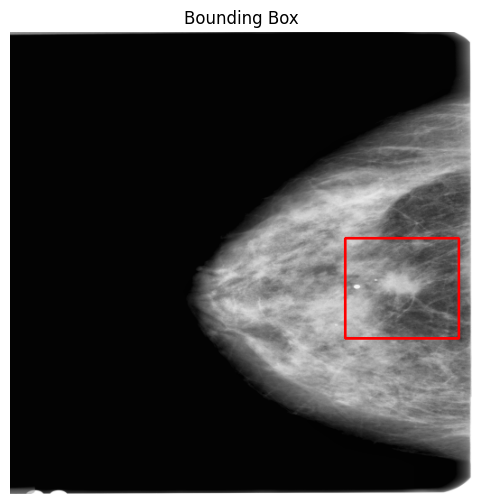

In [96]:
import cv2

bbox = cv2.cvtColor((resize_img).copy(), cv2.COLOR_GRAY2RGB)

cv2.rectangle(
    bbox,
    (x1, y1),
    (x2, y2),
    (255,0,0),
    2
)

plt.figure(figsize=(6,6))
plt.imshow(bbox)
plt.title("Bounding Box")
plt.axis("off")

(np.float64(-0.5), np.float64(125.5), np.float64(110.5), np.float64(-0.5))

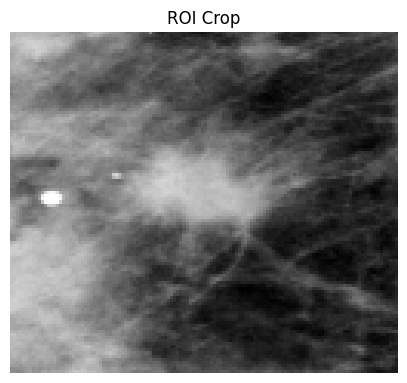

In [97]:
roi = norm_img[y1:y2, x1:x2]

plt.figure(figsize=(5,5))
plt.imshow(roi, cmap="gray")
plt.title("ROI Crop")
plt.axis("off")

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

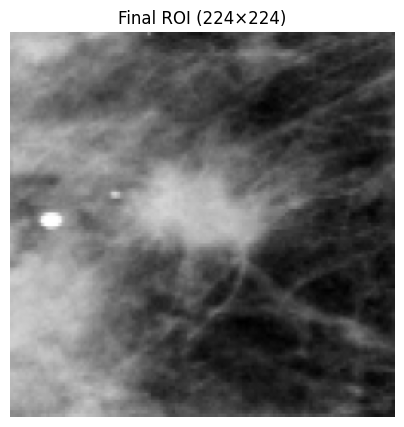

In [98]:
roi = cv2.resize(
    roi,
    (224,224),
    interpolation=cv2.INTER_AREA
)

plt.figure(figsize=(5,5))
plt.imshow(roi,cmap='gray')
plt.title("Final ROI (224×224)")
plt.axis("off")

In [99]:
roi_mask = resize_mask[y1:y2, x1:x2]

roi_mask = cv2.resize(
    roi_mask,
    (224,224),
    interpolation=cv2.INTER_NEAREST
)

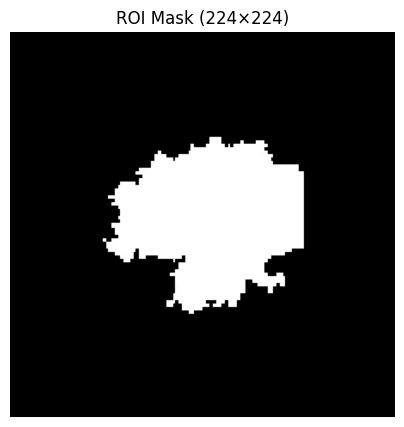

In [100]:
plt.figure(figsize=(5,5))
plt.imshow(roi_mask, cmap="gray")
plt.title("ROI Mask (224×224)")
plt.axis("off")
plt.show()

In [105]:
X = []
Y = []
D = []

for img_path, mask_path, density in pairs:

    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    if img is None or mask is None:
        continue

    # Step 1
    img, mask = orientation_fix(img, mask)

    # Step 2
    img = artifact_removal(img)

    # Step 3
    img = clahe_enhancement(img)

    # Step 4
    img = cv2.GaussianBlur(img, (5,5), 0)

    # Step 5
    img = cv2.resize(img, (512,512))
    mask = cv2.resize(mask, (512,512), interpolation=cv2.INTER_NEAREST)

    mask = (mask > 127).astype(np.uint8)

    # Step 6
    ys, xs = np.where(mask > 0)

    if len(xs) == 0:
        continue

    x1, x2 = xs.min(), xs.max()
    y1, y2 = ys.min(), ys.max()

    PAD = 40

    x1 = max(0, x1-PAD)
    y1 = max(0, y1-PAD)
    x2 = min(511, x2+PAD)
    y2 = min(511, y2+PAD)

    roi = img[y1:y2, x1:x2]
    roi_mask = mask[y1:y2, x1:x2]

    roi = cv2.resize(roi, (224,224))
    roi_mask = cv2.resize(
        roi_mask,
        (224,224),
        interpolation=cv2.INTER_NEAREST
    )

    roi_mask = (roi_mask > 0).astype(np.uint8)

    # Store
    X.append(roi)
    Y.append(roi_mask)
    D.append(density)

In [106]:
X = np.array(X, dtype=np.uint8)
Y = np.array(Y, dtype=np.uint8)
D = np.array(D, dtype=np.uint8)

print(X.shape)
print(Y.shape)
print(D.shape)

(1696, 224, 224)
(1696, 224, 224)
(1696,)


In [107]:
import os
import cv2
import numpy as np

SAVE_DIR = "/content/drive/MyDrive/Mammogram_Project/Density_ROI_Dataset"

os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(f"{SAVE_DIR}/images", exist_ok=True)
os.makedirs(f"{SAVE_DIR}/masks", exist_ok=True)

# Save every ROI image and mask
for i in range(len(X)):
    cv2.imwrite(f"{SAVE_DIR}/images/{i:04d}.png", X[i])
    cv2.imwrite(f"{SAVE_DIR}/masks/{i:04d}.png", Y[i] * 255)

# Save numpy arrays
np.save(f"{SAVE_DIR}/density_roi_x.npy", X)
np.save(f"{SAVE_DIR}/density_roi_y.npy", Y)
np.save(f"{SAVE_DIR}/density_labels.npy", D)

print("===================================")
print("Saved Successfully!")
print("Images :", len(X))
print("Masks  :", len(Y))
print("Labels :", len(D))
print("Location:", SAVE_DIR)

Saved Successfully!
Images : 1696
Masks  : 1696
Labels : 1696
Location: /content/drive/MyDrive/Mammogram_Project/Density_ROI_Dataset


In [108]:
import os

print(os.listdir(SAVE_DIR))

['images', 'masks', 'density_roi_x.npy', 'density_roi_y.npy', 'density_labels.npy']


In [109]:
labels = np.load("/content/drive/MyDrive/Mammogram_Project/Density_ROI_Dataset/density_labels.npy")

print(labels.shape)
print(np.unique(labels, return_counts=True))

(1696,)
(array([1, 2, 3, 4], dtype=uint8), array([337, 757, 449, 153]))


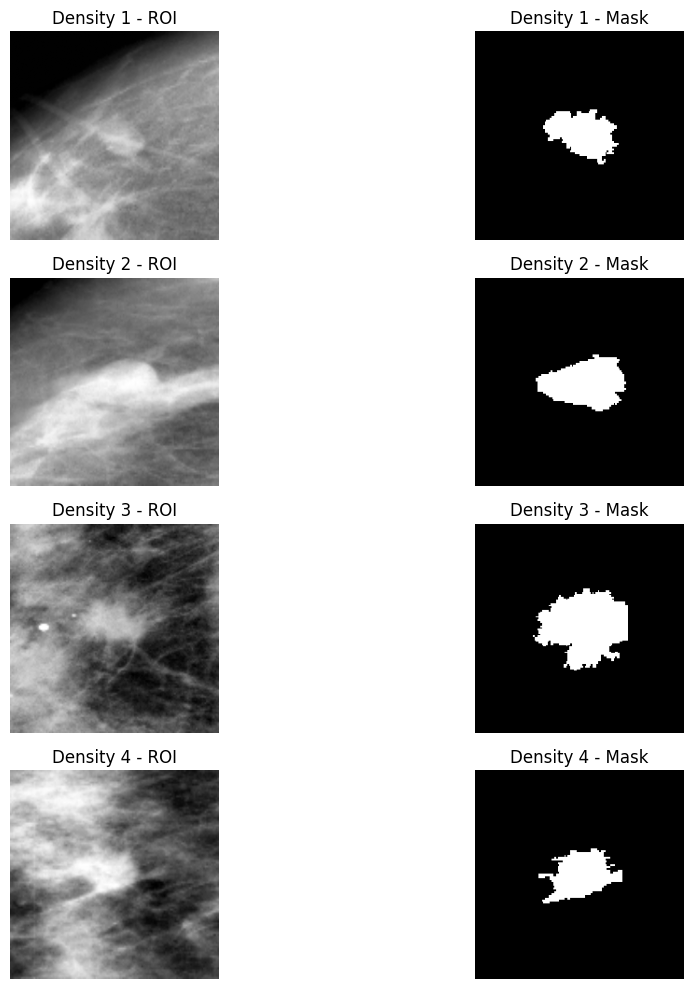

In [110]:
import numpy as np
import matplotlib.pyplot as plt

# Load data
X = np.load("/content/drive/MyDrive/Mammogram_Project/Density_ROI_Dataset/density_roi_x.npy")
Y = np.load("/content/drive/MyDrive/Mammogram_Project/Density_ROI_Dataset/density_roi_y.npy")
D = np.load("/content/drive/MyDrive/Mammogram_Project/Density_ROI_Dataset/density_labels.npy")

densities = [1, 2, 3, 4]

plt.figure(figsize=(12, 10))

for i, d in enumerate(densities):

    idx = np.where(D == d)[0][0]   # first sample of this density

    # ROI image
    plt.subplot(4, 2, 2*i+1)
    plt.imshow(X[idx], cmap="gray")
    plt.title(f"Density {d} - ROI")
    plt.axis("off")

    # ROI mask
    plt.subplot(4, 2, 2*i+2)
    plt.imshow(Y[idx], cmap="gray")
    plt.title(f"Density {d} - Mask")
    plt.axis("off")

plt.tight_layout()
plt.show()